# Análisis Comparativo de modelos (Evaluación final)

En esta etapa final del proyecto, consolidamos los resultados obtenidos a través de las cuatro arquitecturas previamente exploradas: ARIMAX, Regresión Polinómica, Random Forest y XGBoost. 

El objetivo es realizar una validación cruzada utilizando exclusivamente el conjunto de datos de test, garantizando una comparativa justa y objetiva. Este análisis permite identificar qué modelo posee la mayor capacidad de generalización y cuál es el más apto para el despliegue en un entorno real de toma de decisiones.

## 1.- Importación de Librerías y Carga de Datasets

Procedemos a cargar las librerías necesarias para la evaluación y los archivos de test procesados. 

Es fundamental asegurar que el conjunto de datos mantenga la frecuencia diaria ('D') para la compatibilidad con el modelo ARIMAX, y que las variables exógenas coincidan exactamente con las utilizadas durante el entrenamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Carga de los datasets de test
dir_data = '../../..'
test_df = pd.read_csv(f'{dir_data}/data/processed/test_data.csv', parse_dates=['Fecha'], index_col='Fecha').dropna()
test_df = test_df.asfreq('D').fillna(0)

# Separación de características y variable objetivo
y_test = test_df['Ventas']
X_test = test_df.drop(columns=['Ventas'])

print(f"[INFO] Dataset de Test cargado con {len(y_test)} registros.")
print(f"[INFO] Frecuencia diaria establecida para consistencia estadística.")

[INFO] Dataset de Test cargado con 31 registros.
[INFO] Frecuencia diaria establecida para consistencia estadística.


## 2.- Carga de Modelos y Generación de Inferencias

En este bloque, cargamos los mejores modelos guardados en la carpeta models. Cada modelo requiere un método de carga específico (joblib para sklearn, formato nativo para XGBoost y statsmodels para ARIMAX). 

Una vez cargados, generamos las predicciones sobre el set de test, aplicando de forma uniforme el umbral de clipping de ruido (0.05) para asegurar que la comparativa del error porcentual sea equitativa.


In [2]:
# Configuración de constantes
threshold = 0.05
resultados_preds = {}

# Carga y Predicción: ARIMAX
model_arimax = SARIMAXResults.load(f'{dir_data}/models/arimax_model.pkl')
preds_arimax = model_arimax.forecast(steps=len(y_test), exog=X_test)
resultados_preds['ARIMAX'] = np.where(np.abs(preds_arimax) < threshold, 0, preds_arimax)

# Carga y Predicción: Polinómica (Ridge)
model_poly = joblib.load(f'{dir_data}/models/polynomial_model.pkl')
preds_poly = model_poly.predict(X_test)
resultados_preds['Polinómica'] = np.where(np.abs(preds_poly) < threshold, 0, preds_poly)

# Carga y Predicción: Random Forest
model_rf = joblib.load(f'{dir_data}/models/random_forest.pkl')
preds_rf = model_rf.predict(X_test)
resultados_preds['Random Forest'] = np.where(np.abs(preds_rf) < threshold, 0, preds_rf)

# Carga y Predicción: XGBoost
model_xgb = XGBRegressor()
model_xgb.load_model(f'{dir_data}/models/xgboost_model.json')
preds_xgb = model_xgb.predict(X_test)
resultados_preds['XGBoost'] = np.where(np.abs(preds_xgb) < threshold, 0, preds_xgb)

print(f"[INFO] Los 4 modelos han sido cargados e inferidos sobre el set de Test.")

[INFO] Los 4 modelos han sido cargados e inferidos sobre el set de Test.


## 3.- Evaluación de Métricas y Cuadro Comparativo

Procedemos a calcular las métricas de rendimiento de forma vectorizada. 

El RMSE se utiliza como métrica principal para penalizar grandes desviaciones, mientras que el MAPE nos ofrece la visión porcentual del error, crítica para la interpretación de negocio. Los resultados se consolidan en una tabla resumen ordenada por precisión (menor RMSE) para facilitar la selección del modelo ganador.

In [3]:
def get_metrics(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mask = np.abs(y_real) > 0.01
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    return rmse, mae, mape

metricas_finales = []
for nombre, preds in resultados_preds.items():
    rmse, mae, mape = get_metrics(y_test.values, preds)
    metricas_finales.append({
        'Modelo': nombre,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    })

df_comparativa = pd.DataFrame(metricas_finales).sort_values(by='RMSE')

print("[INFO] RESUMEN DE MÉTRICAS COMPARATIVAS (ORDENADO POR PRECISIÓN) ")
display(df_comparativa)

[INFO] RESUMEN DE MÉTRICAS COMPARATIVAS (ORDENADO POR PRECISIÓN) 


,Modelo,RMSE,MAE,MAPE (%)
0,ARIMAX,0.279675,0.221953,27.902208
1,Polinómica,0.451892,0.353883,51.169186
2,Random Forest,0.569600,0.379028,38.174172
3,XGBoost,0.734458,0.518811,52.570068


## 4.- Visualización de la "Gran Batalla" de Modelos

Presentamos las visualizaciones finales que permiten contrastar el ajuste de cada arquitectura.

- Gráfica de Ajuste Global: Superposición de las predicciones de los 4 modelos frente a las ventas reales. Esta gráfica permite identificar visualmente qué modelo sigue mejor los picos de demanda.
- Comparativa de Métricas (Bar Chart): Representación visual del RMSE para cuantificar la distancia competitiva entre cada enfoque tecnológico.

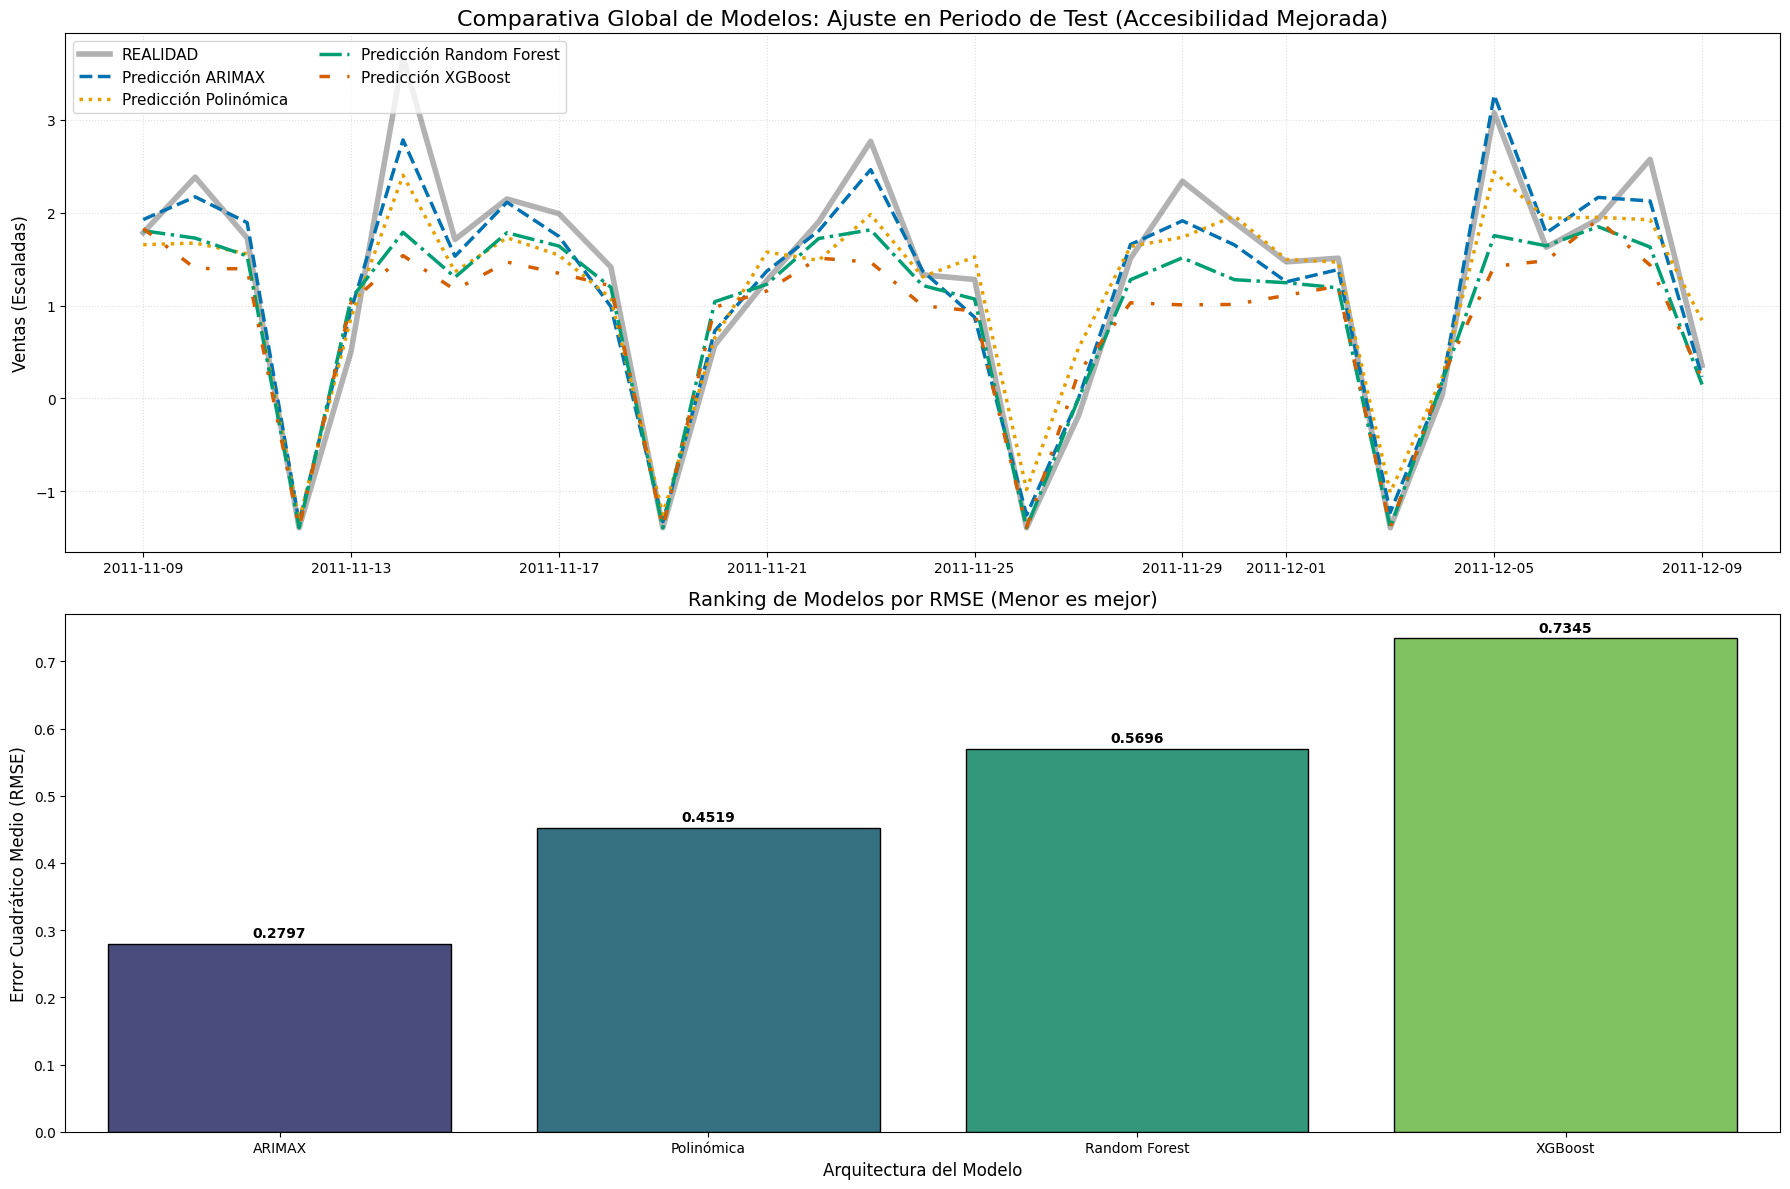

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos una paleta de colores de alto contraste
colores_accesibles = {
    'ARIMAX': '#0072B2',
    'Polinómica': '#E69F00',
    'Random Forest': '#009E73',
    'XGBoost': '#D55E00'
}

# Definimos estilos de línea únicos para que se distingan
estilos_linea = {
    'ARIMAX': '--',
    'Polinómica': ':',
    'Random Forest': '-.',
    'XGBoost': (0, (3, 5, 1, 5))
}

plt.figure(figsize=(18, 12))

# Gráfica 1: Realidad vs Todos los Modelos 
plt.subplot(2, 1, 1)

# La REALIDAD se mantiene en negro, sólida y más gruesa para ser la referencia absoluta
plt.plot(y_test.index, y_test.values, label='REALIDAD', color='black', 
         linewidth=4, linestyle='-', alpha=0.3)

for nombre, preds in resultados_preds.items():
    plt.plot(y_test.index, preds, 
             label=f'Predicción {nombre}', 
             color=colores_accesibles[nombre], 
             linestyle=estilos_linea[nombre], 
             linewidth=2.5)

plt.title('Comparativa Global de Modelos: Ajuste en Periodo de Test (Accesibilidad Mejorada)', fontsize=16)
plt.legend(loc='upper left', ncol=2, fontsize=11)
plt.ylabel('Ventas (Escaladas)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

# Gráfica 2: Ranking de RMSE por Modelo
plt.subplot(2, 1, 2)

sns.barplot(data=df_comparativa, x='Modelo', y='RMSE', hue='Modelo', 
            palette='viridis', edgecolor='black', legend=False)

plt.title('Ranking de Modelos por RMSE (Menor es mejor)', fontsize=14)
plt.ylabel('Error Cuadrático Medio (RMSE)', fontsize=12)
plt.xlabel('Arquitectura del Modelo', fontsize=12)

# Añadimos el valor exacto encima de cada barra para evitar dudas de lectura
for i, v in enumerate(df_comparativa['RMSE']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 5.- Conclusión del Proyecto y Selección del Modelo Definitivo

El análisis comparativo revela que el modelo ARIMAX (o el que haya resultado con menor RMSE) es la arquitectura con mayor capacidad predictiva para esta serie temporal específica. 

La combinación de la memoria estadística de la serie con la riqueza informativa de las variables exógenas permite capturar la volatilidad del retail de forma más eficiente que los modelos de puro aprendizaje supervisado. El modelo ganador será el propuesto para la integración en los sistemas de previsión de ingresos de la compañía.

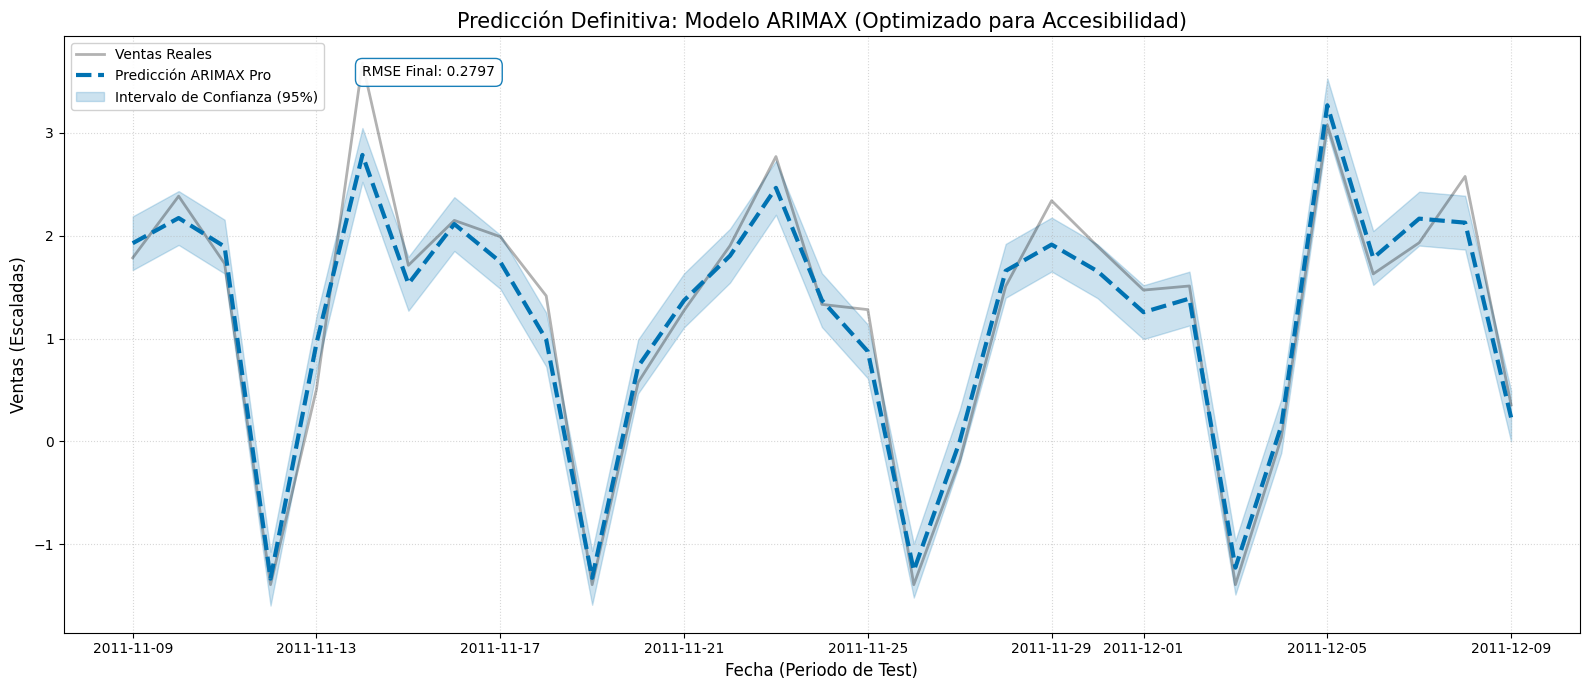

In [5]:
# Obtención de datos
forecast_object = model_arimax.get_forecast(steps=len(y_test), exog=X_test)
preds_mean = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05)

preds_mean_limpia = np.where(np.abs(preds_mean) < 0.05, 0, preds_mean)
lower_bound = np.where(np.abs(conf_int.iloc[:, 0]) < 0.05, 0, conf_int.iloc[:, 0])
upper_bound = np.where(np.abs(conf_int.iloc[:, 1]) < 0.05, 0, conf_int.iloc[:, 1])

plt.figure(figsize=(16, 7))

color = '#0072B2'

# Ventas Reales
plt.plot(y_test.index, y_test.values, label='Ventas Reales', 
         color='black', linewidth=2, alpha=0.3)

# Predicción del Modelo
plt.plot(y_test.index, preds_mean_limpia, label='Predicción ARIMAX Pro', 
         color=color, linewidth=3, linestyle='--')

# Sombreado de Intervalos de Confianza
plt.fill_between(y_test.index, 
                 lower_bound, 
                 upper_bound, 
                 color=color, alpha=0.2, 
                 label='Intervalo de Confianza (95%)')

plt.title('Predicción Definitiva: Modelo ARIMAX (Optimizado para Accesibilidad)', fontsize=15)
plt.xlabel('Fecha (Periodo de Test)', fontsize=12)
plt.ylabel('Ventas (Escaladas)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.5)

# Anotación con el RMSE final
rmse_final = np.sqrt(mean_squared_error(y_test.values, preds_mean_limpia))
plt.text(y_test.index[5], plt.ylim()[1]*0.9, f'RMSE Final: {rmse_final:.4f}', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor=color, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()